# indlæsning af data og libs.

In [350]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

In [351]:
odr = pd.read_csv("data/age-dependency-ratio-old.csv")
internet = pd.read_csv("data/share-of-individuals-using-the-internet.csv")
tfp = pd.read_csv("data/total-factor-productivity.csv") 
patens = pd.read_csv("data/patent-applications-per-million.csv")
hc = pd.read_csv("data/HC.csv")

In [352]:
# Gør HC fra wide til long format
hc_long = hc.melt(
    id_vars=["ISO code", "Country", "Variable code", "Variable name"],
    var_name="year",
    value_name="hc"
)

# Omdøb kolonner så de matcher dine andre datasæt
hc_long = hc_long.rename(columns={
    "ISO code": "code",
    "Country": "country"
})

# Gør year numerisk
hc_long["year"] = pd.to_numeric(hc_long["year"], errors="coerce")

# Fjern rækker uden år eller HC-værdi
hc_long = hc_long.dropna(subset=["year", "hc"])

# Gør year til integer
hc_long["year"] = hc_long["year"].astype(int)

# Begræns perioden, hvis du vil
hc_long = hc_long[(hc_long["year"] >= 1990) & (hc_long["year"] <= 2020)]

# Behold kun de nødvendige kolonner
hc_long = hc_long[["code", "year", "hc"]]

In [353]:
odr = odr.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Age dependency ratio, old (% of working-age population)": "odr"
})

internet = internet.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Share of the population using the Internet": "internet_use"
})

tfp = tfp.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Total factor productivity level": "tfp"
})

patens = patens.rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Patent applications per million people": "patens"
})

# lav begrænsing og merging

In [354]:
start = 2001
end = 2020

lagged_odr = odr.copy()

for df in [odr, tfp, internet, patens, hc_long]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")

odr = odr[(odr["year"] >= start) & (odr["year"] <= end)]
tfp = tfp[(tfp["year"] >= start) & (tfp["year"] <= end)]
internet = internet[(internet["year"] >= start) & (internet["year"] <= end)]
patens = patens[(patens["year"] >= start) & (patens["year"] <= end)]
hc_long = hc_long[(hc_long["year"] >= start) & (hc_long["year"] <= end)]

In [355]:
panel = internet[["country", "code", "year", "internet_use"]].merge(
    odr[["code", "year", "odr"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    tfp[["code", "year", "tfp"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    patens[["code", "year", "patens"]],
    on=["code", "year"],
    how="inner"
)

panel = panel.merge(
    hc_long[["code", "year", "hc"]],
    on=["code", "year"],
    how="inner"
)

#panel.head(30)

In [356]:
# Vælg de variabler, der skal være til stede
required_vars = ["odr", "tfp", "internet_use", "patens", "hc"]   # tilføj evt. flere

# Marker rækker hvor alle nødvendige variabler findes
panel["complete_case"] = panel[required_vars].notna().all(axis=1)

# Tæl hvor mange unikke lande der har komplette data i hvert år
countries_per_year = (
    panel.loc[panel["complete_case"]]
    .groupby("year")["code"]
    .nunique()
    .reset_index(name="n_countries_complete")
    .sort_values("year")
)

print(countries_per_year)

    year  n_countries_complete
0   2001                    75
1   2002                    77
2   2003                    76
3   2004                    76
4   2005                    80
5   2006                    75
6   2007                    83
7   2008                    81
8   2009                    79
9   2010                    81
10  2011                    84
11  2012                    83
12  2013                    87
13  2014                    89
14  2015                    89
15  2016                    91
16  2017                    93
17  2018                    94
18  2019                    89
19  2020                    90


In [357]:
expected_years = end - start + 1

# behold kun lande der har alle år
balanced_codes = (
    panel.groupby("code")["year"]
    .nunique()
    .loc[lambda x: x == expected_years]
    .index
)

panel_balanced = panel[panel["code"].isin(balanced_codes)].copy()

# sortér pænt
panel_balanced = panel_balanced.sort_values(["code", "year"]).reset_index(drop=True)

print("Antal lande:", panel_balanced["code"].nunique())
print("Antal år pr. land:")
print(panel_balanced.groupby("code")["year"].nunique().value_counts())


Antal lande: 56
Antal år pr. land:
year
20    56
Name: count, dtype: int64


# make mean-intervals

In [358]:
#make a copy of the dataframe
panel_2yr = panel_balanced.copy()

# Lav 2-års perioder
panel_2yr["period_start"] = start + 2 * ((panel_2yr["year"] - start) // 2)
panel_2yr["period_end"] = panel_2yr["period_start"] + 1

# Variabler der skal gennemsnittes
vars_to_average = [
    "tfp",
    "odr",
    "hc", 
    "internet_use",
    "patens",
    "schooling"
]

# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 2-års periode
panel_2yr = (
    panel_2yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_2yr["year"] = panel_2yr["period_start"]

panel_2yr["log_internet_use"] = np.log(panel_2yr["internet_use"])
panel_2yr["log_tfp"] = np.log(panel_2yr["tfp"])
panel_2yr["log_patens"] = np.log(panel_2yr["patens"])

In [359]:
#make a copy of the dataframe
panel_4yr = panel_balanced.copy()

# Lav 4-års perioder
panel_4yr["period_start"] = start + 4 * ((panel_4yr["year"] - start) // 4)
panel_4yr["period_end"] = panel_4yr["period_start"] + 3
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 4-års periode
panel_4yr = (
    panel_4yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_4yr["year"] = panel_4yr["period_start"]

panel_4yr["log_internet_use"] = np.log(panel_4yr["internet_use"])
panel_4yr["log_tfp"] = np.log(panel_4yr["tfp"])
panel_4yr["log_patens"] = np.log(panel_4yr["patens"])

In [360]:
#make a copy of the dataframe
panel_5yr = panel_balanced.copy()

# Lav 5-års perioder
panel_5yr["period_start"] = start + 5 * ((panel_5yr["year"] - start) // 5)
panel_5yr["period_end"] = panel_5yr["period_start"] + 4
# Behold kun dem der faktisk findes i datasættet
vars_to_average = [v for v in vars_to_average if v in panel_2yr.columns]

# Collapse til én række pr. land og 5-års periode
panel_5yr = (
    panel_5yr
    .groupby(["code", "country", "period_start", "period_end"], as_index=False)[vars_to_average]
    .mean()
)

# Lav evt. en year-variabel til FE
panel_5yr["year"] = panel_5yr["period_start"]

panel_5yr["log_internet_use"] = np.log(panel_5yr["internet_use"])
panel_5yr["log_tfp"] = np.log(panel_5yr["tfp"])
panel_5yr["log_patens"] = np.log(panel_5yr["patens"])

In [361]:
panel_balanced["log_internet_use"] = np.log(panel_balanced["internet_use"])
panel_balanced["log_tfp"] = np.log(panel_balanced["tfp"])
panel_balanced["log_patens"] = np.log(panel_balanced["patens"])

# modeller

##### $log(tfp)_it = ODR_it + internet_usage+ patens_it + u_it$

In [362]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "log_internet_use", "patens"]],
    "std_err": results1.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results1.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results1.round(4))

                    coef  std_err  p_value
odr               0.0114   0.0045   0.0115
log_internet_use  0.0685   0.0225   0.0024
patens            0.0001   0.0001   0.0292


In [363]:
# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2 = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use", "patens"]],
    "std_err": results2.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results2.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results2.round(4))

                    coef  std_err  p_value
odr               0.0116   0.0048   0.0154
log_internet_use  0.0696   0.0242   0.0040
patens            0.0001   0.0001   0.0335


In [364]:
# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results3.round(4))

                    coef  std_err  p_value
odr               0.0115   0.0052   0.0285
log_internet_use  0.0695   0.0261   0.0077
patens            0.0001   0.0001   0.0451


In [365]:
# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "patens"]],
    "std_err": results4.bse[["odr", "log_internet_use", "patens"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "patens"]],
})

print(main_results4.round(4))

                    coef  std_err  p_value
odr               0.0115   0.0056   0.0395
log_internet_use  0.0700   0.0275   0.0110
patens            0.0001   0.0001   0.0427


#### results

In [366]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log(internet_use) + patens + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + log(internet_use) + patens + FE(code) + FE(year)

                   1 year   2 years   4 years  5 years 
-------------------------------------------------------
odr              0.0114**  0.0116**  0.0115**  0.0115**
                 (0.0045)  (0.0048)  (0.0052)  (0.0056)
log_internet_use 0.0685*** 0.0696*** 0.0695*** 0.0700**
                 (0.0225)  (0.0242)  (0.0261)  (0.0275)
patens           0.0001**  0.0001**  0.0001**  0.0001**
                 (0.0001)  (0.0001)  (0.0001)  (0.0001)
R-squared        0.7395    0.7450    0.7587    0.7659  
R-squared Adj.   0.7202    0.7103    0.6898    0.6778  
N                1120      560       280       224     
R2               0.739     0.745     0.759     0.766   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


#### $log(tfp)_it = ODR_it + patens_it + u_it$

In [367]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + patens + hc +C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "patens", "hc"]],
    "std_err": results1.bse[["odr", "patens", "hc"]],
    "p_value": results1.pvalues[["odr", "patens", "hc"]],
})

print(main_results1.round(4))

          coef  std_err  p_value
odr     0.0028   0.0043   0.5197
patens  0.0001   0.0001   0.0977
hc     -0.1264   0.0900   0.1605


In [368]:
# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + patens + hc+ C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "patens", "hc"]],
    "std_err": results2.bse[["odr", "patens", "hc"]],
    "p_value": results2.pvalues[["odr", "patens", "hc"]],
})

print(main_results2.round(4))

          coef  std_err  p_value
odr     0.0028   0.0045   0.5372
patens  0.0001   0.0001   0.1070
hc     -0.1259   0.0934   0.1773


In [369]:
# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "patens", "hc"]],
    "std_err": results3.bse[["odr", "patens", "hc"]],
    "p_value": results3.pvalues[["odr", "patens", "hc"]],
})

print(main_results3.round(4))

          coef  std_err  p_value
odr     0.0026   0.0049   0.5877
patens  0.0001   0.0001   0.1267
hc     -0.1239   0.1015   0.2222


In [370]:
# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "patens", "hc"]],
    "std_err": results4.bse[["odr", "patens", "hc"]],
    "p_value": results4.pvalues[["odr", "patens", "hc"]],
})

print(main_results4.round(4))

          coef  std_err  p_value
odr     0.0026   0.0052   0.6216
patens  0.0002   0.0001   0.1235
hc     -0.1273   0.1088   0.2419


### Results

In [371]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'patens', 'hc'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + patens + hc + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + patens + hc + FE(code) + FE(year)

                1 year  2 years  4 years  5 years 
--------------------------------------------------
odr            0.0028   0.0028   0.0026   0.0026  
               (0.0043) (0.0045) (0.0049) (0.0052)
patens         0.0001*  0.0001   0.0001   0.0002  
               (0.0001) (0.0001) (0.0001) (0.0001)
hc             -0.1264  -0.1259  -0.1239  -0.1273 
               (0.0900) (0.0934) (0.1015) (0.1088)
R-squared      0.7093   0.7156   0.7323   0.7407  
R-squared Adj. 0.6879   0.6769   0.6558   0.6431  
N              1120     560      280      224     
R2             0.709    0.716    0.732    0.741   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [372]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results1.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results1.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results1.round(4))

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results2.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results2.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results2.round(4))

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results3.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results3.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results3.round(4))

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + log_internet_use + hc + patens + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "log_internet_use", "hc", "patens"]],
    "std_err": results4.bse[["odr", "log_internet_use", "hc", "patens"]],
    "p_value": results4.pvalues[["odr", "log_internet_use", "hc", "patens"]],
})

print(main_results4.round(4))

                    coef  std_err  p_value
odr               0.0110   0.0045   0.0149
log_internet_use  0.0738   0.0226   0.0011
hc               -0.1861   0.0908   0.0404
patens            0.0001   0.0001   0.0122
                    coef  std_err  p_value
odr               0.0112   0.0048   0.0191
log_internet_use  0.0751   0.0243   0.0020
hc               -0.1860   0.0943   0.0486
patens            0.0001   0.0001   0.0145
                    coef  std_err  p_value
odr               0.0111   0.0052   0.0337
log_internet_use  0.0754   0.0266   0.0046
hc               -0.1843   0.1026   0.0724
patens            0.0002   0.0001   0.0217
                    coef  std_err  p_value
odr               0.0112   0.0056   0.0452
log_internet_use  0.0765   0.0280   0.0064
hc               -0.1902   0.1084   0.0794
patens            0.0002   0.0001   0.0195


In [373]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr', 'log_internet_use', 'hc', 'patens'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + log_internet_use + hc + patens + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + log_internet_use + hc + patens + FE(code) + FE(year)

                   1 year   2 years   4 years   5 years 
--------------------------------------------------------
odr              0.0110**  0.0112**  0.0111**  0.0112** 
                 (0.0045)  (0.0048)  (0.0052)  (0.0056) 
log_internet_use 0.0738*** 0.0751*** 0.0754*** 0.0765***
                 (0.0226)  (0.0243)  (0.0266)  (0.0280) 
hc               -0.1861** -0.1860** -0.1843*  -0.1902* 
                 (0.0908)  (0.0943)  (0.1026)  (0.1084) 
patens           0.0001**  0.0001**  0.0002**  0.0002** 
                 (0.0001)  (0.0001)  (0.0001)  (0.0001) 
R-squared        0.7482    0.7537    0.7670    0.7745   
R-squared Adj.   0.7293    0.7196    0.6990    0.6877   
N                1120      560       280       224      
R2               0.748     0.754     0.767     0.775    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [374]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr"]],
    "std_err": results1.bse[["odr"]],
    "p_value": results1.pvalues[["odr"]],
})

print(main_results1.round(4))

# kopi af det færdige balanced panel
df_est = panel_2yr.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr"]],
    "std_err": results2.bse[["odr"]],
    "p_value": results2.pvalues[["odr"]],
})

print(main_results2.round(4))

# kopi af det færdige balanced panel
df_est = panel_4yr.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr"]],
    "std_err": results3.bse[["odr"]],
    "p_value": results3.pvalues[["odr"]],
})

print(main_results3.round(4))

# kopi af det færdige balanced panel
df_est = panel_5yr.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr"]],
    "std_err": results4.bse[["odr"]],
    "p_value": results4.pvalues[["odr"]],
})

print(main_results4.round(4))

       coef  std_err  p_value
odr  0.0018   0.0039   0.6515
       coef  std_err  p_value
odr  0.0017    0.004   0.6712
       coef  std_err  p_value
odr  0.0015   0.0043   0.7331
       coef  std_err  p_value
odr  0.0012   0.0045   0.7836


In [375]:
results = summary_col(
    [results1, results2, results3, results4],
    stars=True,
    model_names=['1 year', '2 years', '4 years', '5 years'],
    regressor_order=['odr'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr  + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr  + FE(code) + FE(year)

                1 year  2 years  4 years  5 years 
--------------------------------------------------
odr            0.0018   0.0017   0.0015   0.0012  
               (0.0039) (0.0040) (0.0043) (0.0045)
R-squared      0.6923   0.6983   0.7146   0.7216  
R-squared Adj. 0.6701   0.6586   0.6365   0.6215  
N              1120     560      280      224     
R2             0.692    0.698    0.715    0.722   
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [376]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr"]],
    "std_err": results1.bse[["odr"]],
    "p_value": results1.pvalues[["odr"]],
})

print(main_results1.round(4))

# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "patens"]],
    "std_err": results2.bse[["odr", "patens"]],
    "p_value": results2.pvalues[["odr", "patens"]],
})

print(main_results2.round(4))

# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "patens", "hc"]],
    "std_err": results3.bse[["odr", "patens", "hc"]],
    "p_value": results3.pvalues[["odr", "patens", "hc"]],
})

print(main_results3.round(4))

# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + patens + hc + log_internet_use + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "patens", "hc", "log_internet_use"]],
    "std_err": results4.bse[["odr", "patens", "hc", "log_internet_use"]],
    "p_value": results4.pvalues[["odr", "patens", "hc", "log_internet_use"]],
})

print(main_results4.round(4))
panel_balanced["odr_sqr"] = panel_balanced["odr"] ** 2
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()


# estimation
model5 = smf.ols(
    "log_tfp ~ odr + odr_sqr + patens + hc + log_internet_use + C(code) + C(year)",
    data=df_est
)

results5 = model5.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results5 = pd.DataFrame({
    "coef": results5.params[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
    "std_err": results5.bse[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
    "p_value": results5.pvalues[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
})

print(main_results5.round(4))

       coef  std_err  p_value
odr  0.0018   0.0039   0.6515
          coef  std_err  p_value
odr     0.0035   0.0041   0.4011
patens  0.0001   0.0001   0.1227
          coef  std_err  p_value
odr     0.0028   0.0043   0.5197
patens  0.0001   0.0001   0.0977
hc     -0.1264   0.0900   0.1605
                    coef  std_err  p_value
odr               0.0110   0.0045   0.0149
patens            0.0001   0.0001   0.0122
hc               -0.1861   0.0908   0.0404
log_internet_use  0.0738   0.0226   0.0011
                    coef  std_err  p_value
odr               0.0311   0.0100   0.0018
odr_sqr          -0.0003   0.0002   0.0524
patens            0.0001   0.0001   0.1793
hc               -0.2070   0.0917   0.0240
log_internet_use  0.0754   0.0222   0.0007


In [377]:
results = summary_col(
    [results1, results2, results3, results4, results5],
    stars=True,
    model_names=['ODR', '+ Patens', '+ HC', '+ Internet', 'tfp'],
    regressor_order=['odr', 'patens', 'hc', 'log_internet_use'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + patens + hc + log_internet_use + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + patens + hc + log_internet_use + FE(code) + FE(year)

                   ODR    + Patens   + HC   + Internet    tfp   
----------------------------------------------------------------
odr              0.0018   0.0035   0.0028   0.0110**   0.0311***
                 (0.0039) (0.0041) (0.0043) (0.0045)   (0.0100) 
patens                    0.0001   0.0001*  0.0001**   0.0001   
                          (0.0001) (0.0001) (0.0001)   (0.0001) 
hc                                 -0.1264  -0.1861**  -0.2070**
                                   (0.0900) (0.0908)   (0.0917) 
log_internet_use                            0.0738***  0.0754***
                                            (0.0226)   (0.0222) 
R-squared        0.6923   0.7052   0.7093   0.7482     0.7547   
R-squared Adj.   0.6701   0.6837   0.6879   0.7293     0.7361   
N                1120     1120     1120     1120       1120     
R2               0.692    0.705    0.709    0.748      0.755    
Standard errors in 

In [378]:
# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model0 = smf.ols(
    "log_tfp ~ odr + C(code) + C(year)",
    data=df_est
)

results0 = model0.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results0 = pd.DataFrame({
    "coef": results0.params[["odr"]],
    "std_err": results0.bse[["odr"]],
    "p_value": results0.pvalues[["odr"]],
})

# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model1 = smf.ols(
    "log_tfp ~ odr + odr_sqr + C(code) + C(year)",
    data=df_est
)

results1 = model1.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results1 = pd.DataFrame({
    "coef": results1.params[["odr", "odr_sqr"]],
    "std_err": results1.bse[["odr", "odr_sqr"]],
    "p_value": results1.pvalues[["odr", "odr_sqr"]],
})



# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model2 = smf.ols(
    "log_tfp ~ odr + odr_sqr + patens + C(code) + C(year)",
    data=df_est
)

results2 = model2.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results2  = pd.DataFrame({
    "coef": results2.params[["odr", "odr_sqr", "patens"]],
    "std_err": results2.bse[["odr", "odr_sqr", "patens"]],
    "p_value": results2.pvalues[["odr", "odr_sqr", "patens"]],
})



# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model3 = smf.ols(
    "log_tfp ~ odr + odr_sqr + patens + hc + C(code) + C(year)",
    data=df_est
)

results3 = model3.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results3 = pd.DataFrame({
    "coef": results3.params[["odr", "odr_sqr", "patens", "hc"]],
    "std_err": results3.bse[["odr", "odr_sqr", "patens", "hc"]],
    "p_value": results3.pvalues[["odr", "odr_sqr", "patens", "hc"]],
})

# kopi af det færdige balanced panel
df_est = panel_balanced.copy()

# estimation
model4 = smf.ols(
    "log_tfp ~ odr + odr_sqr + patens + hc + log_internet_use + C(code) + C(year)",
    data=df_est
)

results4 = model4.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_est["code"]}
)

main_results4 = pd.DataFrame({
    "coef": results4.params[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
    "std_err": results4.bse[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
    "p_value": results4.pvalues[["odr", "odr_sqr", "patens", "hc", "log_internet_use"]],
})


In [379]:
results = summary_col(
    [results0, results1, results2, results3, results4],
    stars=True,
    model_names=['ODR', '+ord_sqr','+ Patens', '+ HC', '+ Internet'],
    regressor_order=['odr', 'odr_sqr', 'patens', 'hc', 'log_internet_use'],
    drop_omitted=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R2': lambda x: f"{x.rsquared:.3f}"
    }
)

#print the model
print("log(tfp) ~ odr + patens + hc + log_internet_use + FE(code) + FE(year)")
print(results)

log(tfp) ~ odr + patens + hc + log_internet_use + FE(code) + FE(year)

                   ODR     +ord_sqr + Patens   + HC   + Internet
----------------------------------------------------------------
odr              0.0018   0.0262**  0.0187   0.0201   0.0311*** 
                 (0.0039) (0.0120)  (0.0121) (0.0124) (0.0100)  
odr_sqr                   -0.0004** -0.0003  -0.0003  -0.0003*  
                          (0.0002)  (0.0002) (0.0002) (0.0002)  
patens                              0.0001   0.0001   0.0001    
                                    (0.0001) (0.0001) (0.0001)  
hc                                           -0.1434  -0.2070** 
                                             (0.0934) (0.0917)  
log_internet_use                                      0.0754*** 
                                                      (0.0222)  
R-squared        0.6923   0.7051    0.7091   0.7143   0.7547    
R-squared Adj.   0.6701   0.6836    0.6876   0.6929   0.7361    
N                11

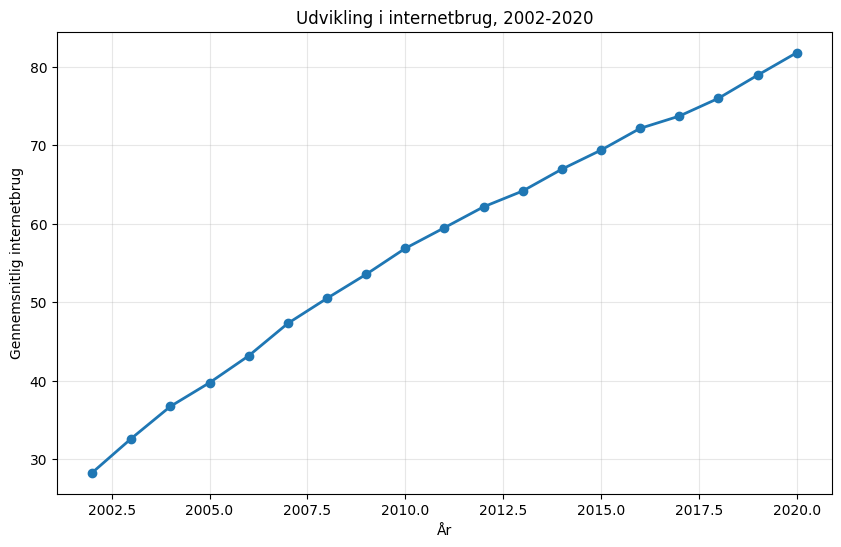

In [380]:
# Kopi af balanced panel
df_plot = panel_balanced.copy()

# Afgræns perioden
df_plot = df_plot[(df_plot["year"] >= 2002) & (df_plot["year"] <= 2020)]

# Vælg internetvariabel
# Ret navnet, hvis din variabel hedder noget andet
internet_var = "internet_use"

# Beregn gennemsnit pr. år
internet_year = (
    df_plot
    .groupby("year")[internet_var]
    .mean()
    .reset_index()
)

#plot all contries


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    internet_year["year"],
    internet_year[internet_var],
    marker="o",
    linewidth=2
)

plt.title("Udvikling i internetbrug, 2002-2020")
plt.xlabel("År")
plt.ylabel("Gennemsnitlig internetbrug")
plt.grid(True, alpha=0.3)

plt.show()

In [381]:
countries_to_drop = ["CHL", "FRA", "ISR", "MDA", "PHL", "ESP"]

panel_internet_filtered = panel_balanced[
    ~panel_balanced["code"].isin(countries_to_drop)
].copy()

print("Antal lande før:", panel_balanced["code"].nunique())
print("Antal lande efter:", panel_internet_filtered["code"].nunique())

print("Fjernede lande:")
print(
    panel_balanced[panel_balanced["code"].isin(countries_to_drop)]
    [["country", "code"]]
    .drop_duplicates()
    .sort_values("country")
)

Antal lande før: 56
Antal lande efter: 50
Fjernede lande:
         country code
140        Chile  CHL
360       France  FRA
540       Israel  ISR
700      Moldova  MDA
840  Philippines  PHL
300        Spain  ESP


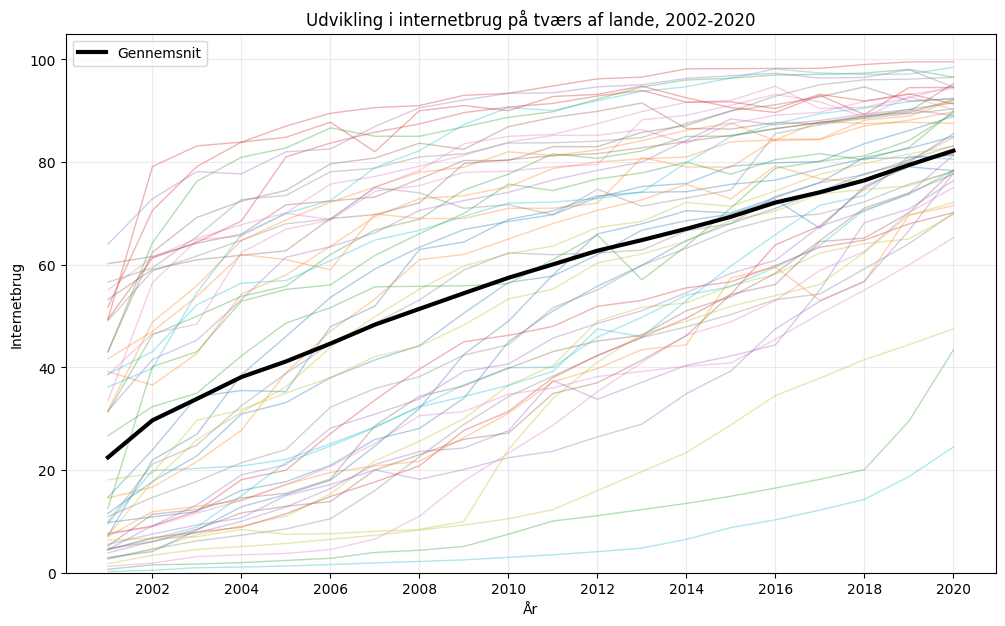

In [383]:
# Kopi af balanced panel
df_plot = panel_internet_filtered.copy()

# Ret variabelnavnet, hvis din internetvariabel hedder noget andet
internet_var = "internet_use"

plt.figure(figsize=(12, 7))

# Plot hvert land
for country in df_plot["country"].unique():
    country_data = df_plot[df_plot["country"] == country]
    
    plt.plot(
        country_data["year"],
        country_data[internet_var],
        linewidth=1,
        alpha=0.35
    )

# Beregn gennemsnit på tværs af lande
internet_mean = (
    df_plot
    .groupby("year")[internet_var]
    .mean()
    .reset_index()
)

# Plot gennemsnittet tydeligere
plt.plot(
    internet_mean["year"],
    internet_mean[internet_var],
    linewidth=3,
    color="black",
    label="Gennemsnit"
)

plt.title("Udvikling i internetbrug på tværs af lande, 2002-2020")
plt.xlabel("År")
plt.ylabel("Internetbrug")
plt.xticks(range(2002, 2021, 2))
plt.ylim(0, 105)
plt.grid(True, alpha=0.25)
plt.legend()

plt.show()